In [1]:
import json
import os
import re
from pathlib import Path
from typing import Dict, Any, List

import pandas as pd

# this should point to the directory containing the results
ROOT = Path("../data/final_results")

# Output Excel file
OUT_XLSX = ROOT / "master_logo_table.xlsx"

In [2]:
EPS = 1e-9

def parse_run_metadata(path: Path) -> Dict[str, Any]:
    """
    Extract metadata from a path like:
    .../WITH_FEATURE_ENGINEERING/logo/exp_1_FINAL_merged_collar_herde_weather/results.json
    """
    parts = path.parts

    # Feature engineering flag
    fe_flag = None
    if "WITH_FEATURE_ENGINEERING" in parts:
        fe_flag = True
    elif "NO_FEATURE_ENGINEERING" in parts:
        fe_flag = False

    # exp id (if present)
    exp = None
    m = re.search(r"exp_(\d+)", str(path))
    if m:
        exp = int(m.group(1))

    eval_kind = "logo" if "logo" in parts else None

    # experiment folder (directory containing results.json)
    exp_folder = path.parent.name

    # Variant name: strip leading exp_N_
    variant_name = re.sub(r"^exp_\d+_", "", exp_folder)

    # Guess feature_set from "...merged_*"
    m2 = re.search(r"merged_(.+)$", variant_name)
    feature_set = m2.group(1) if m2 else variant_name

    return {
        "path": str(path),
        "feature_engineering": fe_flag,
        "eval_kind": eval_kind,
        "exp_id": exp,
        "exp_folder": exp_folder,
        "variant_name": variant_name,
        "feature_set": feature_set,
    }


def load_logo_results(json_path: Path) -> Dict[str, Dict[str, Any]]:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise ValueError(f"Unexpected JSON root type in {json_path}: {type(data)}")
    return data


In [3]:
def build_master_logo_table(root: Path) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []

    for json_path in sorted(root.rglob("results.json")):
        # Restrict to LOGO only
        if f"{os.sep}logo{os.sep}" not in str(json_path):
            continue

        meta = parse_run_metadata(json_path)
        results = load_logo_results(json_path)

        for cow_id_str, metrics in results.items():
            # Skip any non-cow keys
            if not str(cow_id_str).isdigit():
                continue

            row = dict(meta)
            row["cow_id"] = int(cow_id_str)

            if isinstance(metrics, dict):
                for k, v in metrics.items():
                    if isinstance(v, (int, float, str, bool)) or v is None:
                        row[k] = v
            else:
                row["metrics_raw"] = str(metrics)

            # Convenience columns
            support_lying = row.get("support_lying")
            support_standing = row.get("support_standing")

            # Sometimes these are floats in your JSON; treat as numeric
            support_lying = float(support_lying) if support_lying is not None else 0.0
            support_standing = float(support_standing) if support_standing is not None else 0.0

            row["support_total"] = support_lying + support_standing
            row["lying_ratio_obs"] = (
                support_lying / (row["support_total"] + EPS)
                if row["support_total"] > 0
                else None
            )

            rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(
            f"No LOGO results.json files found under {root}. "
            f"Check ROOT and folder structure."
        )

    # Put key columns first if they exist
    preferred = [
        "cow_id",
        "feature_engineering",
        "feature_set",
        "variant_name",
        "exp_id",
        "eval_kind",
        "macro_f1",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_lying",
        "f1_standing",
        "support_lying",
        "support_standing",
        "support_total",
        "lying_ratio_obs",
        "use_markov",
        "path",
    ]
    cols = [c for c in preferred if c in df.columns] + [c for c in df.columns if c not in preferred]
    df = df[cols]

    return df


master_logo_df = build_master_logo_table(ROOT)
master_logo_df.shape


(899, 25)

In [4]:
master_logo_df

,cow_id,feature_engineering,feature_set,variant_name,exp_id,eval_kind,macro_f1,balanced_accuracy,precision,recall,...,lying_ratio_obs,use_markov,path,exp_folder,macro_f1_raw,balanced_accuracy_raw,precision_raw,recall_raw,f1_lying_raw,f1_standing_raw
0,15543,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.305,0.438356,0.500,0.219,...,1.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.305,0.438356,0.500,0.219,0.609524,0.000000
1,15553,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.474,0.902098,0.500,0.451,...,0.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.474,0.902098,0.500,0.451,0.000000,0.948529
2,15554,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.787,0.780954,0.795,0.781,...,0.372294,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.787,0.780954,0.795,0.781,0.723926,0.849498
3,15558,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.262,0.354167,0.500,0.177,...,1.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.262,0.354167,0.500,0.177,0.523077,0.000000
4,15564,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.674,0.663636,0.704,0.664,...,0.312500,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.674,0.663636,0.704,0.664,0.522523,0.826230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
894,99739,True,collar_herde_weather,FINAL_merged_collar_herde_weather,3,logo,0.681,0.629630,0.952,0.630,...,0.125581,False,../data/final_results/WITH_FEATURE_ENGINEERING...,exp_3_FINAL_merged_collar_herde_weather,0.681,0.629630,0.952,0.630,0.411765,0.949495
895,99740,True,collar_herde_weather,FINAL_merged_collar_herde_weather,3,logo,1.000,1.000000,1.000,1.000,...,0.097087,False,../data/final_results/WITH_FEATURE_ENGINEERING...,exp_3_FINAL_merged_collar_herde_weather,1.000,1.000000,1.000,1.000,1.000000,1.000000
896,99741,True,collar_herde_weather,FINAL_merged_collar_herde_weather,3,logo,1.000,1.000000,1.000,1.000,...,0.057325,False,../data/final_results/WITH_FEATURE_ENGINEERING...,exp_3_FINAL_merged_collar_herde_weather,1.000,1.000000,1.000,1.000,1.000000,1.000000
897,99745,True,collar_herde_weather,FINAL_merged_collar_herde_weather,3,logo,1.000,1.000000,1.000,1.000,...,0.305970,False,../data/final_results/WITH_FEATURE_ENGINEERING...,exp_3_FINAL_merged_collar_herde_weather,1.000,1.000000,1.000,1.000,1.000000,1.000000


In [5]:
master_logo_df = master_logo_df[master_logo_df['feature_engineering'] == False]
master_logo_df



,cow_id,feature_engineering,feature_set,variant_name,exp_id,eval_kind,macro_f1,balanced_accuracy,precision,recall,...,lying_ratio_obs,use_markov,path,exp_folder,macro_f1_raw,balanced_accuracy_raw,precision_raw,recall_raw,f1_lying_raw,f1_standing_raw
0,15543,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.305,0.438356,0.500,0.219,...,1.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.305,0.438356,0.500,0.219,0.609524,0.000000
1,15553,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.474,0.902098,0.500,0.451,...,0.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.474,0.902098,0.500,0.451,0.000000,0.948529
2,15554,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.787,0.780954,0.795,0.781,...,0.372294,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.787,0.780954,0.795,0.781,0.723926,0.849498
3,15558,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.262,0.354167,0.500,0.177,...,1.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.262,0.354167,0.500,0.177,0.523077,0.000000
4,15564,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.674,0.663636,0.704,0.664,...,0.312500,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.674,0.663636,0.704,0.664,0.522523,0.826230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,99731,False,collar_herde_weather_bolus,FINAL_merged_collar_herde_weather_bolus,5,logo,1.000,1.000000,1.000,1.000,...,0.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_5_FINAL_merged_collar_herde_weather_bolus,1.000,1.000000,1.000,1.000,NaN,1.000000
583,99735,False,collar_herde_weather_bolus,FINAL_merged_collar_herde_weather_bolus,5,logo,1.000,1.000000,1.000,1.000,...,0.015873,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_5_FINAL_merged_collar_herde_weather_bolus,1.000,1.000000,1.000,1.000,1.000000,1.000000
584,99738,False,collar_herde_weather_bolus,FINAL_merged_collar_herde_weather_bolus,5,logo,1.000,1.000000,1.000,1.000,...,0.085586,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_5_FINAL_merged_collar_herde_weather_bolus,1.000,1.000000,1.000,1.000,1.000000,1.000000
585,99739,False,collar_herde_weather_bolus,FINAL_merged_collar_herde_weather_bolus,5,logo,1.000,1.000000,1.000,1.000,...,0.125581,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_5_FINAL_merged_collar_herde_weather_bolus,1.000,1.000000,1.000,1.000,1.000000,1.000000


In [6]:
master_logo_df = master_logo_df[master_logo_df['eval_kind'] == 'logo']
master_logo_df

,cow_id,feature_engineering,feature_set,variant_name,exp_id,eval_kind,macro_f1,balanced_accuracy,precision,recall,...,lying_ratio_obs,use_markov,path,exp_folder,macro_f1_raw,balanced_accuracy_raw,precision_raw,recall_raw,f1_lying_raw,f1_standing_raw
0,15543,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.305,0.438356,0.500,0.219,...,1.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.305,0.438356,0.500,0.219,0.609524,0.000000
1,15553,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.474,0.902098,0.500,0.451,...,0.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.474,0.902098,0.500,0.451,0.000000,0.948529
2,15554,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.787,0.780954,0.795,0.781,...,0.372294,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.787,0.780954,0.795,0.781,0.723926,0.849498
3,15558,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.262,0.354167,0.500,0.177,...,1.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.262,0.354167,0.500,0.177,0.523077,0.000000
4,15564,False,collar_herde_bolus_weather,2025_merged_collar_herde_bolus_weather,1,logo,0.674,0.663636,0.704,0.664,...,0.312500,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_1_2025_merged_collar_herde_bolus_weather,0.674,0.663636,0.704,0.664,0.522523,0.826230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,99731,False,collar_herde_weather_bolus,FINAL_merged_collar_herde_weather_bolus,5,logo,1.000,1.000000,1.000,1.000,...,0.000000,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_5_FINAL_merged_collar_herde_weather_bolus,1.000,1.000000,1.000,1.000,NaN,1.000000
583,99735,False,collar_herde_weather_bolus,FINAL_merged_collar_herde_weather_bolus,5,logo,1.000,1.000000,1.000,1.000,...,0.015873,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_5_FINAL_merged_collar_herde_weather_bolus,1.000,1.000000,1.000,1.000,1.000000,1.000000
584,99738,False,collar_herde_weather_bolus,FINAL_merged_collar_herde_weather_bolus,5,logo,1.000,1.000000,1.000,1.000,...,0.085586,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_5_FINAL_merged_collar_herde_weather_bolus,1.000,1.000000,1.000,1.000,1.000000,1.000000
585,99739,False,collar_herde_weather_bolus,FINAL_merged_collar_herde_weather_bolus,5,logo,1.000,1.000000,1.000,1.000,...,0.125581,False,../data/final_results/NO_FEATURE_ENGINEERING/l...,exp_5_FINAL_merged_collar_herde_weather_bolus,1.000,1.000000,1.000,1.000,1.000000,1.000000


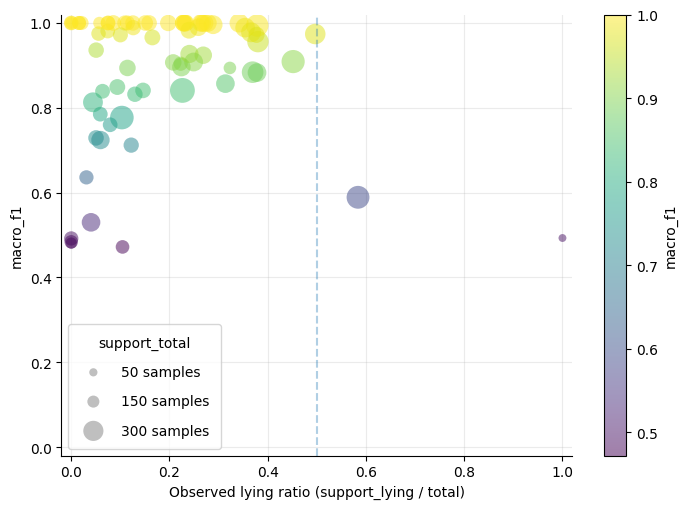

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_lying_vs_macro_f1_bubble(
    df,
    run_filter=None,
    x_col="lying_ratio_obs",
    y_col="macro_f1",
    n_col="support_total",
    size_range=(30, 320),
    gamma=2.0,
    color_by="macro_f1",
    cmap="viridis",
    alpha=0.45,
    show_vline_05=True,
):
    sub = df.copy()

    if run_filter:
        for k, v in run_filter.items():
            sub = sub[sub[k] == v]

    sub = sub.dropna(subset=[x_col, y_col, n_col]).copy()

    x = sub[x_col].astype(float).to_numpy()
    y = sub[y_col].astype(float).to_numpy()
    n = sub[n_col].astype(float).to_numpy()

    if np.any(n <= 0):
        raise ValueError(f"{n_col} must be > 0.")

    # exaggerated nonlinear size mapping
    n_norm = n / np.max(n)
    s_norm = n_norm ** gamma
    s = size_range[0] + s_norm * (size_range[1] - size_range[0])

    # color
    c = sub[color_by].astype(float).to_numpy() if color_by else None

    plt.rcParams.update({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
    })

    fig, ax = plt.subplots(figsize=(7.2, 5.2))

    sc = ax.scatter(
        x, y,
        s=s,
        c=c,
        cmap=cmap if c is not None else None,
        alpha=alpha,
        edgecolors="none",
    )

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Observed lying ratio (support_lying / total)")
    ax.set_ylabel(y_col)

    if show_vline_05:
        ax.axvline(0.5, linestyle="--", alpha=0.35)

    if c is not None:
        cb = plt.colorbar(sc, ax=ax)
        cb.set_label(color_by)

    # size legend (use meaningful supports)
    legend_vals = np.array([50, 150, 300])
    legend_vals = legend_vals[legend_vals <= np.max(n)]

    legend_norm = (legend_vals / np.max(n)) ** gamma
    legend_sizes = size_range[0] + legend_norm * (size_range[1] - size_range[0])

    handles = [plt.scatter([], [], s=sv, color="gray", alpha=alpha, edgecolors="none") for sv in legend_sizes]
    labels = [f"{int(v)} samples" for v in legend_vals]

    ax.legend(
        handles, labels,
        title="support_total",
        loc="lower left",
        frameon=True,
        labelspacing=1.1,
        borderpad=0.8,
        handletextpad=1.0,
    )

    plt.tight_layout()
    plt.show()


# Example:
plot_lying_vs_macro_f1_bubble(
    master_logo_df,
    run_filter={"feature_engineering": False, "feature_set": "collar_herde_weather_bolus", "exp_id": 5},
    color_by="macro_f1",
    alpha=0.5
)


# LOGO tail analysis

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# master_logo should already exist from the earlier notebook
# it must contain at least: cow_id, macro_f1, lying_ratio_obs, feature_engineering, feature_set, exp_id
required = ["cow_id", "macro_f1", "lying_ratio_obs", "feature_engineering", "feature_set", "exp_id"]
missing = [c for c in required if c not in master_logo_df.columns]
if missing:
    raise ValueError(f"master_logo is missing columns: {missing}")

df = master_logo_df.copy()

# Keep LOGO only (just in case)
if "eval_kind" in df.columns:
    df = df[df["eval_kind"] == "logo"].copy()


In [9]:
def tail_ids_by_group(df_group: pd.DataFrame, k: int = 8) -> set:
    g = df_group.sort_values("macro_f1", ascending=True)
    return set(g.head(k)["cow_id"].astype(int).tolist())


In [17]:
def plot_logo_tail_facets(
    df: pd.DataFrame,
    metric: str = "macro_f1",
    k_label: int = 0,          # set to >0 to label worst cows per plot
    max_cols: int = 2,
    figsize_per_ax=(6, 4),
):
    # Grouping keys that define one "run"
    run_keys = ["feature_engineering", "feature_set", "exp_id"]
    for k in run_keys:
        if k not in df.columns:
            raise ValueError(f"Missing grouping column: {k}")

    runs = (
        df[run_keys]
        .drop_duplicates()
        .sort_values(run_keys)
        .to_dict("records")
    )

    n = len(runs)
    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))

    fig_w = figsize_per_ax[0] * ncols
    fig_h = figsize_per_ax[1] * nrows
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), squeeze=False)

    for i, run in enumerate(runs):
        r = i // ncols
        c = i % ncols
        ax = axes[r][c]

        sub = df.copy()
        for k, v in run.items():
            sub = sub[sub[k] == v]

        # Drop missing ratios/metrics
        sub = sub.dropna(subset=["lying_ratio_obs", metric])

        x = sub["lying_ratio_obs"].astype(float).to_numpy()
        y = sub[metric].astype(float).to_numpy()

        ax.scatter(x, y, alpha=0.8)

        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlabel("Observed lying ratio (support_lying / total)")
        ax.set_ylabel(metric)

        title = f"FE={run['feature_engineering']} | {run['feature_set']} | exp_{run['exp_id']}"
        ax.set_title(title)

        # Optional: label tail cows (worst k)
        if k_label and k_label > 0 and "cow_id" in sub.columns:
            tail_ids = tail_ids_by_group(sub, k=k_label)
            tail = sub[sub["cow_id"].isin(tail_ids)].sort_values(metric)

            for _, row in tail.iterrows():
                ax.annotate(
                    str(int(row["cow_id"])),
                    (float(row["lying_ratio_obs"]), float(row[metric])),
                    xytext=(4, 4),
                    textcoords="offset points",
                    fontsize=8
                )

        # Add a reference line at 0.5 lying ratio (just a visual anchor)
        ax.axvline(0.5, linewidth=1)

    # Turn off unused axes
    for j in range(n, nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r][c].axis("off")

    plt.tight_layout()
    plt.show()

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: best-in-class collision avoidance (recommended)
# pip install adjustText
try:
    from adjustText import adjust_text
    _HAS_ADJUSTTEXT = True
except Exception:
    _HAS_ADJUSTTEXT = False


def tail_ids_by_group(sub: pd.DataFrame, k: int, metric: str = "macro_f1"):
    """
    Returns cow_ids for the worst-k rows by metric within 'sub'.
    Assumes one row per cow for that run; if not, it will take the worst row per cow.
    """
    if "cow_id" not in sub.columns:
        return []

    tmp = sub.copy()
    # If multiple rows per cow exist, keep worst metric per cow
    tmp = tmp.sort_values(metric, ascending=True).drop_duplicates("cow_id", keep="first")
    return tmp.nsmallest(k, metric)["cow_id"].tolist()


def _greedy_nonoverlap_text(
    ax,
    xs,
    ys,
    labels,
    *,
    fontsize=8,
    offsets=((4, 4), (4, -4), (-4, 4), (-4, -4), (8, 0), (0, 8), (-8, 0), (0, -8)),
    pad_px=2,
    max_iter_offsets=None,
):
    """
    Pure-matplotlib fallback: greedy placement using multiple offsets.
    Uses pixel-space bounding boxes to prevent overlaps with already placed labels.
    Keeps as many labels as possible, skipping those that can't be placed cleanly.
    """
    fig = ax.figure
    renderer = fig.canvas.get_renderer()

    texts = []
    occupied = []

    if max_iter_offsets is None:
        max_iter_offsets = len(offsets)

    for x, y, lab in zip(xs, ys, labels):
        placed = False

        # try each offset until one doesn't overlap
        for (dx, dy) in offsets[:max_iter_offsets]:
            t = ax.annotate(
                str(lab),
                (x, y),
                xytext=(dx, dy),
                textcoords="offset points",
                fontsize=fontsize,
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
            )

            # Need a draw to get accurate bbox
            fig.canvas.draw_idle()
            fig.canvas.flush_events()

            bbox = t.get_window_extent(renderer=renderer).expanded(1.0, 1.0)
            # add padding
            bbox = bbox.from_extents(bbox.x0 - pad_px, bbox.y0 - pad_px, bbox.x1 + pad_px, bbox.y1 + pad_px)

            overlaps = any(bbox.overlaps(b) for b in occupied)
            if overlaps:
                t.remove()
                continue

            occupied.append(bbox)
            texts.append(t)
            placed = True
            break

        if not placed:
            # skip label if no offset works
            pass

    return texts


def plot_logo_tail_facets(
    df: pd.DataFrame,
    metric: str = "macro_f1",
    k_label: int = 0,                 # label worst cows per plot
    max_cols: int = 2,
    figsize_per_ax=(6, 4),
    modern_style: bool = True,
    use_adjusttext: bool = True,      # uses adjustText if available
    adjusttext_arrow: bool = False,   # arrows can add clutter; default off
):
    """
    Faceted scatter plots: lying_ratio_obs vs metric, grouped by
    feature_engineering / feature_set / exp_id, with optional non-overlapping annotations
    for the worst-k cows.

    - If adjustText is installed and use_adjusttext=True, it will maximize labels cleanly.
    - Otherwise uses a greedy pixel-bbox non-overlap fallback.
    """
    run_keys = ["feature_engineering", "feature_set", "exp_id"]
    for k in run_keys:
        if k not in df.columns:
            raise ValueError(f"Missing grouping column: {k}")

    # Optional: a cleaner default look (no bold usage)
    if modern_style:
        plt.rcParams.update({
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.25,
            "grid.linewidth": 0.8,
            "axes.axisbelow": True,
            "font.size": 10,
        })

    runs = (
        df[run_keys]
        .drop_duplicates()
        .sort_values(run_keys)
        .to_dict("records")
    )

    # Your original code kept runs[1:] (skip the first one). Keeping that behavior:
    runs = runs[1:]

    n = len(runs)
    if n == 0:
        raise ValueError("No runs to plot after applying runs = runs[1:].")

    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))

    fig_w = figsize_per_ax[0] * ncols
    fig_h = figsize_per_ax[1] * nrows
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), squeeze=False)

    for i, run in enumerate(runs):
        r = i // ncols
        c = i % ncols
        ax = axes[r][c]

        sub = df.copy()
        for k, v in run.items():
            sub = sub[sub[k] == v]

        sub = sub.dropna(subset=["lying_ratio_obs", metric])

        x = sub["lying_ratio_obs"].astype(float).to_numpy()
        y = sub[metric].astype(float).to_numpy()

        ax.scatter(x, y, alpha=0.85, s=36)

        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)

        if i == 0:
            ax.set_xlabel("Observed lying ratio (support_lying / total)\nBolus subset (collar only)")
        else:
            ax.set_xlabel("Observed lying ratio (support_lying / total)\nBolus subset (collar + bolus + weather)")
        ax.set_ylabel(metric)
        title = (
            f"FE={run['feature_engineering']} | "
            f"feature_set={run['feature_set']} | exp={run['exp_id']} | n={len(sub)}"
        )
        ax.set_title(title, fontsize=10)
        ax.axvline(0.5, linewidth=1)

        # Non-overlapping tail annotations
        if k_label and k_label > 0 and "cow_id" in sub.columns:
            tail_ids = tail_ids_by_group(sub, k=k_label, metric=metric)
            tail = sub[sub["cow_id"].isin(tail_ids)].sort_values(metric, ascending=True)

            tx = tail["lying_ratio_obs"].astype(float).to_numpy()
            ty = tail[metric].astype(float).to_numpy()
            tlab = tail["cow_id"].astype(int).to_numpy()

            # Prefer adjustText if available (best results)
            if use_adjusttext and _HAS_ADJUSTTEXT:
                texts = []
                for xx, yy, lab in zip(tx, ty, tlab):
                    texts.append(
                        ax.text(xx, yy, str(lab), fontsize=8)
                    )

                arrowprops = None
                if adjusttext_arrow:
                    arrowprops = dict(arrowstyle="-", lw=0.6, alpha=0.7)

                # Encourage moving text around while keeping points fixed
                adjust_text(
                    texts,
                    ax=ax,
                    expand_text=(1.05, 1.15),
                    expand_points=(1.05, 1.15),
                    force_text=(0.2, 0.4),
                    force_points=(0.05, 0.1),
                    only_move={"text": "xy"},
                    arrowprops=arrowprops,
                )
            else:
                # Fallback: greedy pixel-bbox collision avoidance
                # Important: ensure a draw so we have a renderer available
                fig.canvas.draw()
                _greedy_nonoverlap_text(
                    ax,
                    tx,
                    ty,
                    tlab,
                    fontsize=8,
                    offsets=((4, 4), (4, -4), (-4, 4), (-4, -4), (10, 0), (0, 10), (-10, 0), (0, -10)),
                    pad_px=2,
                )

    # Turn off unused axes
    for j in range(n, nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r][c].axis("off")

    plt.tight_layout()
    plt.show()

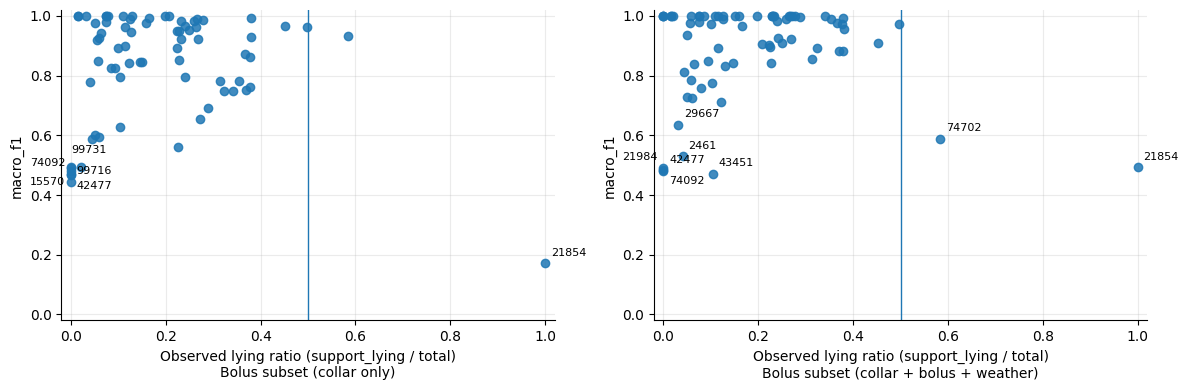

In [ ]:
plot_logo_tail_facets(df, metric="macro_f1", k_label=8, max_cols=2)

In [50]:
def consistently_hard_cows(df: pd.DataFrame, metric: str = "macro_f1", tail_quantile: float = 0.10):
    run_keys = ["feature_engineering", "feature_set", "exp_id"]
    sub = df.dropna(subset=[metric]).copy()

    marks = []
    for _, run in sub[run_keys].drop_duplicates().iterrows():
        run_df = sub[
            (sub["feature_engineering"] == run["feature_engineering"]) &
            (sub["feature_set"] == run["feature_set"]) &
            (sub["exp_id"] == run["exp_id"])
        ].copy()

        if run_df.empty:
            continue

        thresh = run_df[metric].quantile(tail_quantile)
        run_df["is_tail"] = run_df[metric] <= thresh
        marks.append(run_df[["cow_id"] + run_keys + [metric, "lying_ratio_obs", "is_tail"]])

    marks = pd.concat(marks, ignore_index=True)

    # Count how often each cow is in the tail per feature_set (+FE)
    summary = (
        marks.groupby(["feature_engineering", "feature_set", "cow_id"], dropna=False)["is_tail"]
        .mean()
        .reset_index()
        .rename(columns={"is_tail": f"tail_rate_bottom_{int(tail_quantile*100)}pct"})
        .sort_values(f"tail_rate_bottom_{int(tail_quantile*100)}pct", ascending=False)
    )

    return marks, summary


marks, hard = consistently_hard_cows(df, metric="macro_f1", tail_quantile=0.10)
hard.head(20)


,feature_engineering,feature_set,cow_id,tail_rate_bottom_10pct
135,False,collar_herde_weather_bolus,21854,1.0
18,False,collar_herde_weather,15570,1.0
86,False,collar_herde_weather,99716,1.0
70,False,collar_herde_weather,90352,1.0
66,False,collar_herde_weather,75082,1.0
60,False,collar_herde_weather,74092,1.0
50,False,collar_herde_weather,42477,1.0
93,False,collar_herde_weather,99727,1.0
137,False,collar_herde_weather_bolus,21984,1.0
39,False,collar_herde_weather,37431,1.0


# DISTRIBUTION VS LOGO PERFORMANCE

/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_68329/592248973.py:27: DtypeWarning: Columns (8,31,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/luka/priv_projects/moomotion/data/FINAL_merged_collar_herde_weather_bolus.csv")
/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_68329/592248973.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logo_scores.rename(columns={'cow_id':ANIMAL_COL}, inplace=True)


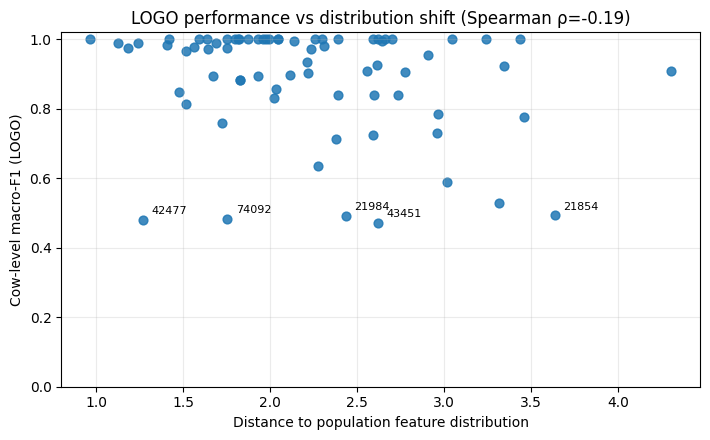

    animal_id  support_total    z_dist  mahal_dist
16      15560            200  5.645940    4.886130
10      15014            197  5.645940    4.886130
14      15554            353  0.847094    4.305578
33      21854            139  4.977288    3.638533
40      42474            359  1.191227    3.460189
22      15576            262  0.287955    3.435421
19      15569            254  0.832038    3.345183
4        2461            273  1.677545    3.318872
11      15543            258  0.398749    3.244309
1        2457            211  0.319948    3.044162


In [ ]:
from __future__ import annotations

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/luka/priv_projects/moomotion/data/FINAL_merged_collar_herde_weather_bolus.csv")


ANIMAL_COL = "animal_id"
EXPERIMENT_ID = 5

logo_scores = master_logo_df[master_logo_df['exp_id']==EXPERIMENT_ID]
logo_scores.rename(columns={'cow_id':ANIMAL_COL}, inplace=True)

# Distance settings
USE_ROBUST_Z = True          # robust z using median/MAD
USE_MAHALANOBIS = True       # try Mahalanobis; will fallback safely
COV_SHRINKAGE = 1e-3         # stabilizes covariance inversion

# Plot settings
FIGSIZE = (7.2, 4.5)         # thesis-friendly
ALPHA = 0.85
S = 40


def find_imu_tick_cols(columns: list[str]) -> list[str]:
    pat = re.compile(r"^IMU_Tick_Count_(\d+)mG$")
    cols = []
    for c in columns:
        m = pat.match(c)
        if m:
            cols.append(c)
    # sort by threshold value
    cols.sort(key=lambda x: int(pat.match(x).group(1)))
    return cols

def robust_center_scale(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns (center, scale) using median and MAD.
    scale uses 1.4826*MAD to approximate std under normality.
    """
    center = np.nanmedian(X, axis=0)
    mad = np.nanmedian(np.abs(X - center), axis=0)
    scale = 1.4826 * mad
    # avoid divide-by-zero
    scale = np.where(scale == 0, 1.0, scale)
    return center, scale

def mean_std_center_scale(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    center = np.nanmean(X, axis=0)
    scale = np.nanstd(X, axis=0, ddof=1)
    scale = np.where((scale == 0) | np.isnan(scale), 1.0, scale)
    return center, scale

def mahalanobis_distance(X: np.ndarray, center: np.ndarray, cov: np.ndarray) -> np.ndarray:
    """
    Computes Mahalanobis distance of each row of X to 'center' with covariance 'cov'.
    """
    Xc = X - center
    # add ridge to covariance for numerical stability
    cov_reg = cov + np.eye(cov.shape[0]) * COV_SHRINKAGE
    inv_cov = np.linalg.inv(cov_reg)
    # d^2 = x^T inv_cov x
    d2 = np.einsum("ij,jk,ik->i", Xc, inv_cov, Xc)
    d = np.sqrt(np.maximum(d2, 0))
    return d

def spearmanr_safe(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    """
    Spearman correlation without SciPy. Returns (rho, approx_p).
    p-value is approximate (normal approximation). Good enough for an exploratory figure caption.
    If you have SciPy, replace with scipy.stats.spearmanr.
    """
    # rank with average ties
    xr = pd.Series(x).rank(method="average").to_numpy()
    yr = pd.Series(y).rank(method="average").to_numpy()
    xr = xr - xr.mean()
    yr = yr - yr.mean()
    denom = (np.sqrt((xr**2).sum()) * np.sqrt((yr**2).sum()))
    rho = float((xr * yr).sum() / denom) if denom > 0 else np.nan

    # approximate p-value using t approximation (rough)
    n = np.isfinite(x).sum()
    if n < 4 or not np.isfinite(rho):
        return rho, np.nan
    t = rho * np.sqrt((n - 2) / max(1e-12, (1 - rho**2)))
    # two-sided p from normal approx of t (rough)
    # Use erf approximation:
    from math import erf, sqrt
    p = 2 * (1 - 0.5 * (1 + erf(abs(t) / sqrt(2))))
    return rho, p


imu_cols = find_imu_tick_cols(list(df.columns))
if not imu_cols:
    raise ValueError("No IMU tick columns found. Expected columns like 'IMU_Tick_Count_80mG'.")

needed = [ANIMAL_COL] + imu_cols
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_feat = df[needed].copy()

# Ensure numeric
for c in imu_cols:
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")

# Drop rows with no animal_id
df_feat = df_feat.dropna(subset=[ANIMAL_COL])

# Optional: drop rows where all IMU are NaN
df_feat = df_feat.dropna(subset=imu_cols, how="all")


cow_agg = (
    df_feat.groupby(ANIMAL_COL)[imu_cols]
    .agg(["mean", "std", "count"])
)

# Flatten multiindex columns
cow_agg.columns = ["_".join(col).strip() for col in cow_agg.columns.to_flat_index()]
cow_agg = cow_agg.reset_index()

# Keep a simple support measure: min count across IMU columns
count_cols = [f"{c}_count" for c in imu_cols]
cow_agg["support_total"] = cow_agg[count_cols].min(axis=1)

# Build matrix of per-cow means (this is what we measure distance on)
mean_cols = [f"{c}_mean" for c in imu_cols]
X = cow_agg[mean_cols].to_numpy(dtype=float)

if USE_ROBUST_Z:
    center_z, scale_z = robust_center_scale(X)
else:
    center_z, scale_z = mean_std_center_scale(X)

Z = (X - center_z) / scale_z
cow_agg["z_dist"] = np.sqrt(np.nanmean(Z**2, axis=1))  # RMS z distance

# Mahalanobis distance
if USE_MAHALANOBIS:
    # covariance of per-cow means
    # Use nan-safe covariance: fill remaining NaNs with column center
    X_cov = X.copy()
    nan_mask = np.isnan(X_cov)
    if nan_mask.any():
        X_cov[nan_mask] = np.take(center_z, np.where(nan_mask)[1])
    cov = np.cov(X_cov, rowvar=False)
    try:
        cow_agg["mahal_dist"] = mahalanobis_distance(X_cov, center=np.nanmean(X_cov, axis=0), cov=cov)
    except np.linalg.LinAlgError:
        cow_agg["mahal_dist"] = np.nan

# Choose distance to plot (prefer mahal if it worked)
dist_col = "mahal_dist" if (USE_MAHALANOBIS and cow_agg["mahal_dist"].notna().any()) else "z_dist"


if logo_scores is None:
    # You can still inspect cow_agg and later merge
    print("logo_scores is None: plotting distance only. Provide per-cow macro_f1 to plot distance vs performance.")
else:
    if isinstance(logo_scores, dict):
        score_df = pd.DataFrame({ANIMAL_COL: list(logo_scores.keys()), "macro_f1": list(logo_scores.values())})
    elif isinstance(logo_scores, pd.DataFrame):
        if ANIMAL_COL not in logo_scores.columns or "macro_f1" not in logo_scores.columns:
            raise ValueError("logo_scores DataFrame must contain columns ['animal_id','macro_f1'].")
        score_df = logo_scores[[ANIMAL_COL, "macro_f1"]].copy()
    else:
        raise TypeError("logo_scores must be a dict or a pandas DataFrame.")

    plot_df = cow_agg.merge(score_df, on=ANIMAL_COL, how="inner")
    plot_df = plot_df.dropna(subset=[dist_col, "macro_f1"])


    plt.figure(figsize=FIGSIZE)
    plt.scatter(
        plot_df[dist_col].to_numpy(),
        plot_df["macro_f1"].to_numpy(),
        s=S,
        alpha=ALPHA,
    )
    plt.xlabel("Distance to population feature distribution")
    plt.ylabel("Cow-level macro-F1 (LOGO)")
    plt.ylim(0.0, 1.02)

    # Optional: annotate a few worst performers
    worst = plot_df.nsmallest(5, "macro_f1")
    for _, r in worst.iterrows():
        plt.annotate(
            str(int(r[ANIMAL_COL])) if pd.api.types.is_numeric_dtype(plot_df[ANIMAL_COL]) else str(r[ANIMAL_COL]),
            (r[dist_col], r["macro_f1"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=8,
        )

    # correlation (Spearman)
    rho, p = spearmanr_safe(plot_df[dist_col].to_numpy(), plot_df["macro_f1"].to_numpy())
    plt.title(f"LOGO performance vs distribution shift (Spearman ρ={rho:.2f})")

    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

# This gives you a cow-level table you can use in appendix or debugging.
out_cols = [ANIMAL_COL, "support_total", "z_dist"]
if "mahal_dist" in cow_agg.columns:
    out_cols.append("mahal_dist")

cow_distance_table = cow_agg[out_cols].sort_values(by=(dist_col if dist_col in cow_agg.columns else "z_dist"), ascending=False)
print(cow_distance_table.head(10))
